# Import Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 30)

# Exploratory Data Analysis

## Load Data

In [3]:
DATA_PATH = Path("dataset/japan_influenza_temperature_analysis_ready.csv")
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}\n")
print(f"Data Information:")
df.info()
display(df.head(10))

Shape: (1522, 26)

Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 1522 entries, 0 to 1521
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   WHOREGION                  1522 non-null   str    
 1   COUNTRY_CODE               1522 non-null   str    
 2   COUNTRY_AREA_TERRITORY     1522 non-null   str    
 3   ISO2                       1522 non-null   str    
 4   HEMISPHERE                 1522 non-null   str    
 5   FLUSEASON                  1522 non-null   str    
 6   ORIGIN_SOURCE              1522 non-null   str    
 7   ISO_WEEKSTARTDATE          1522 non-null   str    
 8   ISO_YEAR                   1522 non-null   int64  
 9   ISO_WEEK                   1522 non-null   int64  
 10  ISOYW                      1522 non-null   int64  
 11  INF_A                      1502 non-null   float64
 12  INF_B                      1504 non-null   float64
 13  INF_ALL               

,WHOREGION,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO2,HEMISPHERE,FLUSEASON,ORIGIN_SOURCE,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,ISOYW,INF_A,INF_B,INF_ALL,SPEC_PROCESSED_NB,INF_NEGATIVE,positive_specimen_count,positive_count_source,positivity_rate_percent,national_mean_temperature,national_min_temperature,national_max_temperature,weekly_temperature_change,location_count,complete_location_count,national_proxy_complete
0,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-07,1996,41,199641,1.0,0.0,1.0,NaN,NaN,1.0,INF_ALL,NaN,17.397143,11.96,23.54,NaN,10,10,True
1,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-14,1996,42,199642,2.0,0.0,2.0,NaN,NaN,2.0,INF_ALL,NaN,15.781429,10.32,21.25,-1.615714,10,10,True
2,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-21,1996,43,199643,1.0,0.0,1.0,NaN,NaN,1.0,INF_ALL,NaN,14.844286,7.93,22.22,-0.937143,10,10,True
3,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-10-28,1996,44,199644,4.0,0.0,4.0,NaN,NaN,4.0,INF_ALL,NaN,15.942857,9.16,22.77,1.098571,10,10,True
4,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-11-04,1996,45,199645,11.0,0.0,11.0,NaN,NaN,11.0,INF_ALL,NaN,14.412857,7.33,20.47,-1.530000,10,10,True
5,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-11-11,1996,46,199646,12.0,0.0,12.0,NaN,NaN,12.0,INF_ALL,NaN,10.325714,4.76,17.77,-4.087143,10,10,True
6,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-11-18,1996,47,199647,25.0,1.0,26.0,NaN,NaN,26.0,INF_ALL,NaN,10.108571,5.12,16.05,-0.217143,10,10,True
7,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-11-25,1996,48,199648,63.0,2.0,65.0,NaN,NaN,65.0,INF_ALL,NaN,8.170000,1.56,15.51,-1.938571,10,10,True
8,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-12-02,1996,49,199649,190.0,4.0,194.0,NaN,NaN,194.0,INF_ALL,NaN,6.055714,0.65,14.66,-2.114286,10,10,True
9,WPR,JPN,Japan,JP,NH,NH,SENTINEL,1996-12-09,1996,50,199650,433.0,3.0,436.0,NaN,NaN,436.0,INF_ALL,NaN,7.492857,2.25,13.04,1.437143,10,10,True


## Structure and ISO week identity

In [5]:
week_key = ["ISO_YEAR", "ISO_WEEK"]
duplicate_week_mask = df.duplicated(week_key, keep=False)
invalid_date_count = int(df["ISO_WEEKSTARTDATE"].isna().sum())
non_monday_count = int((df["ISO_WEEKSTARTDATE"].dropna().dt.dayofweek != 0).sum())

iso_from_date = df["ISO_WEEKSTARTDATE"].dt.isocalendar()
iso_mismatch_mask = (
    iso_from_date["year"].astype("Int64").ne(df["ISO_YEAR"].astype("Int64"))
    | iso_from_date["week"].astype("Int64").ne(df["ISO_WEEK"].astype("Int64"))
).fillna(True)

overview = pd.DataFrame({
    "metric": [
        "Number of rows",
        "Number of columns",
        "Start date",
        "End date",
        "Unique ISO weeks",
        "Rows in duplicate ISO weeks",
        "Invalid dates",
        "Dates that are not Mondays",
        "ISO_YEAR/ISO_WEEK mismatches with date",
    ],
    "value": [
        f"{df.shape[0]:,}",
        f"{df.shape[1]:,}",
        df["ISO_WEEKSTARTDATE"].min().date().isoformat(),
        df["ISO_WEEKSTARTDATE"].max().date().isoformat(),
        f"{df[week_key].drop_duplicates().shape[0]:,}",
        f"{int(duplicate_week_mask.sum()):,}",
        f"{invalid_date_count:,}",
        f"{non_monday_count:,}",
        f"{int(iso_mismatch_mask.sum()):,}",
    ],
})
display(overview)

,metric,value
0,Number of rows,"1,522"
1,Number of columns,26
2,Start date,1996-10-07
3,End date,2026-08-03
4,Unique ISO weeks,"1,522"
5,Rows in duplicate ISO weeks,0
6,Invalid dates,0
7,Dates that are not Mondays,0
8,ISO_YEAR/ISO_WEEK mismatches with date,0


## Missing values in influenza and temperature variables

In [6]:
MEASURE_COLUMNS = [
    "positive_specimen_count",
    "national_mean_temperature",
    "national_min_temperature",
    "national_max_temperature",
    "weekly_temperature_change",
]

missing_summary = pd.DataFrame({
    "missing_n": df[MEASURE_COLUMNS].isna().sum(),
    "missing_percent": df[MEASURE_COLUMNS].isna().mean().mul(100).round(2),
}).rename_axis("variabel")
display(missing_summary)

# Display only weeks with missing influenza values; omit complete rows.
missing_influenza_weeks = df.loc[
    df["positive_specimen_count"].isna(),
    ["ISO_WEEKSTARTDATE", "ISO_YEAR", "ISO_WEEK"],
].copy()
display(Markdown(f"**Weeks with missing `positive_specimen_count`: {len(missing_influenza_weeks):,}**"))
display(missing_influenza_weeks)

,missing_n,missing_percent
variabel,,
positive_specimen_count,17,1.12
national_mean_temperature,0,0.00
national_min_temperature,0,0.00
national_max_temperature,0,0.00
weekly_temperature_change,1,0.07


**Weeks with missing `positive_specimen_count`: 17**

,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK
27,1997-04-21,1997,17
28,1997-06-30,1997,27
31,1997-12-22,1997,52
32,1997-12-29,1998,1
33,1998-01-05,1998,2
35,1998-01-19,1998,4
37,1998-02-02,1998,6
39,1998-02-16,1998,8
40,1998-02-23,1998,9
41,1998-03-02,1998,10


## Location coverage in the temperature proxy

In [7]:
LOCATION_COLUMNS = ["location_count", "complete_location_count", "national_proxy_complete"]
missing_location_columns = [column for column in LOCATION_COLUMNS if column not in df.columns]
if missing_location_columns:
    raise ValueError(f"Location proxy metadata columns not found: {missing_location_columns}")

location_summary = pd.DataFrame({
    "metric": [
        "Minimum locations used per week",
        "Maximum locations used per week",
        "Number of unique location_count values",
        "Weeks with all locations complete",
        "Weeks with an incomplete national proxy",
    ],
    "value": [
        int(df["location_count"].min()),
        int(df["location_count"].max()),
        int(df["location_count"].nunique()),
        int(df["complete_location_count"].eq(df["location_count"]).sum()),
        int(df["national_proxy_complete"].ne(True).sum()),
    ],
})
display(location_summary)

,metric,value
0,Minimum locations used per week,10
1,Maximum locations used per week,10
2,Number of unique location_count values,1
3,Weeks with all locations complete,1522
4,Weeks with an incomplete national proxy,0


## Continuity between consecutive weeks

In [8]:
observed_dates = (
    df["ISO_WEEKSTARTDATE"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)
continuity = pd.DataFrame({"current_week": observed_dates})
continuity["previous_week"] = continuity["current_week"].shift()
continuity["interval_days"] = (
    continuity["current_week"] - continuity["previous_week"]
).dt.days

interval_anomalies = continuity.loc[
    continuity["interval_days"].notna() & continuity["interval_days"].ne(7),
    ["previous_week", "current_week", "interval_days"],
].copy()
interval_anomalies["missing_weeks"] = (
    interval_anomalies["interval_days"].floordiv(7).sub(1).clip(lower=0).astype(int)
)

continuity_summary = pd.DataFrame({
    "metric": ["7-day intervals", "Intervals other than 7 days", "Total calendar weeks without a row"],
    "value": [
        int(continuity["interval_days"].eq(7).sum()),
        len(interval_anomalies),
        int(interval_anomalies["missing_weeks"].sum()),
    ],
})
display(continuity_summary)
display(Markdown("**Non-continuous intervals:**"))
display(interval_anomalies)

,metric,value
0,7-day intervals,1514
1,Intervals other than 7 days,7
2,Total calendar weeks without a row,35


**Non-continuous intervals:**

,previous_week,current_week,interval_days,missing_weeks
27,1997-04-07,1997-04-21,14.0,1
28,1997-04-21,1997-06-30,70.0,9
29,1997-06-30,1997-12-01,154.0,21
31,1997-12-08,1997-12-22,14.0,1
42,1998-03-02,1998-03-16,14.0,1
43,1998-03-16,1998-03-30,14.0,1
185,2000-12-11,2000-12-25,14.0,1


## Weekly coverage visualization

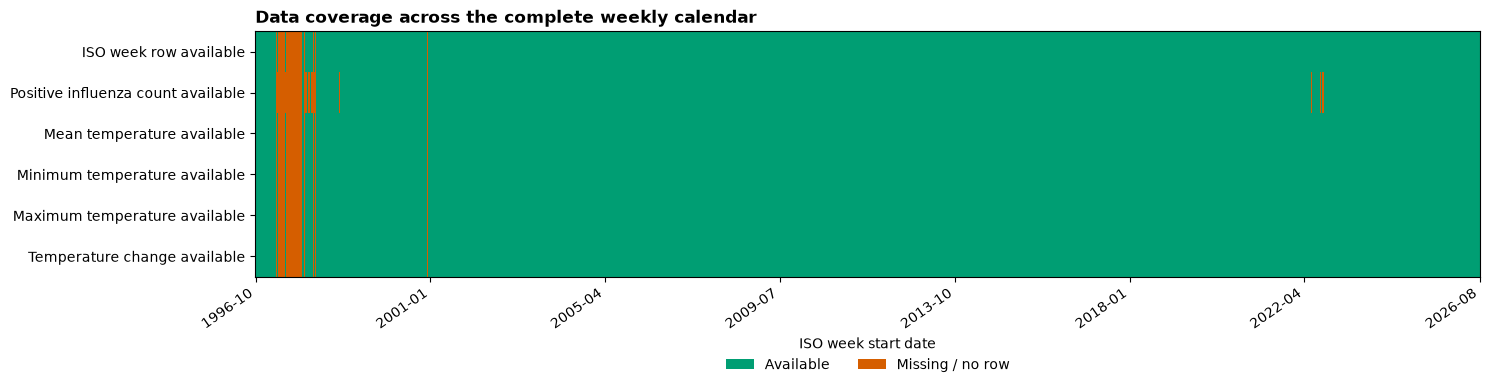

In [9]:
calendar = pd.date_range(
    df["ISO_WEEKSTARTDATE"].min(), df["ISO_WEEKSTARTDATE"].max(), freq="W-MON"
)
weekly = df.set_index("ISO_WEEKSTARTDATE").reindex(calendar)
coverage = pd.DataFrame({
    "ISO week row available": calendar.isin(df["ISO_WEEKSTARTDATE"]),
    "Positive influenza count available": weekly["positive_specimen_count"].notna().to_numpy(),
    "Mean temperature available": weekly["national_mean_temperature"].notna().to_numpy(),
    "Minimum temperature available": weekly["national_min_temperature"].notna().to_numpy(),
    "Maximum temperature available": weekly["national_max_temperature"].notna().to_numpy(),
    "Temperature change available": weekly["weekly_temperature_change"].notna().to_numpy(),
}, index=calendar).T

fig, ax = plt.subplots(figsize=(15, 4.2))
ax.imshow(
    coverage.astype(int), aspect="auto", interpolation="nearest",
    cmap=ListedColormap(["#D55E00", "#009E73"]), vmin=0, vmax=1,
)
tick_positions = np.linspace(0, len(calendar) - 1, 8, dtype=int)
ax.set_xticks(tick_positions, calendar[tick_positions].strftime("%Y-%m"), rotation=35, ha="right")
ax.set_yticks(np.arange(len(coverage)), coverage.index)
ax.set_xlabel("ISO week start date")
ax.set_title("Data coverage across the complete weekly calendar", loc="left", weight="bold")
ax.legend(
    handles=[
        Patch(facecolor="#009E73", label="Available"),
        Patch(facecolor="#D55E00", label="Missing / no row"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=False,
)
fig.tight_layout()
plt.show()

# Period Analysis